In [4]:
pip install "numpy<2"

Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
import numpy as np


In [6]:
df = pd.read_csv("medical_insurance.csv")
print(df.head())
print(df.info())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   object 
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   object 
 5   region    2772 non-null   object 
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 151.7+ KB
None


In [7]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [8]:
df = df.drop_duplicates()

In [9]:
df = pd.get_dummies(df, columns=['sex','smoker','region'], drop_first=True)

In [10]:
def bmi_category(bmi):
    if bmi < 18.5:
        return "Underweight"
    elif bmi < 25:
        return "Normal"
    elif bmi < 30:
        return "Overweight"
    else:
        return "Obese"

df["bmi_category"] = df["bmi"].apply(bmi_category)

In [11]:
df = pd.get_dummies(df, columns=['bmi_category'], drop_first=True)

In [12]:
print(df.columns)

Index(['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_Obese', 'bmi_category_Overweight',
       'bmi_category_Underweight'],
      dtype='object')


In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

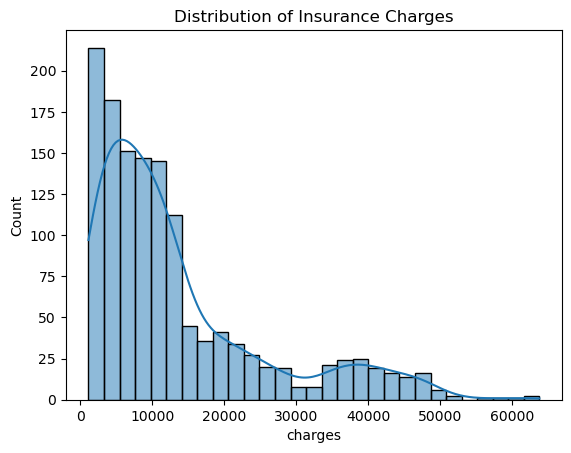

In [14]:
sns.histplot(df["charges"], kde=True)
plt.title("Distribution of Insurance Charges")
plt.show()

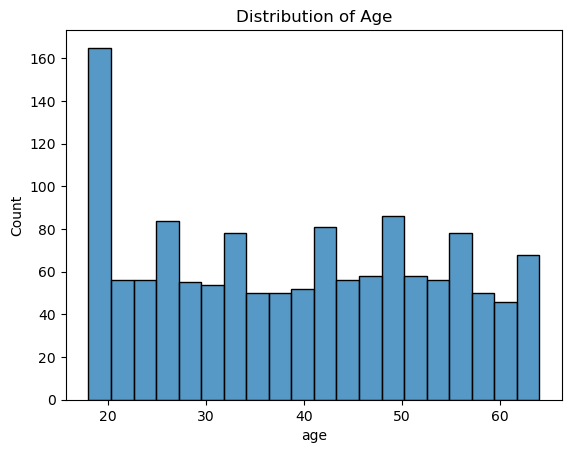

In [15]:
sns.histplot(df["age"], bins=20)
plt.title("Distribution of Age")
plt.show()

Text(0.5, 1.0, 'Count of Smokers vs Non-Smokers')

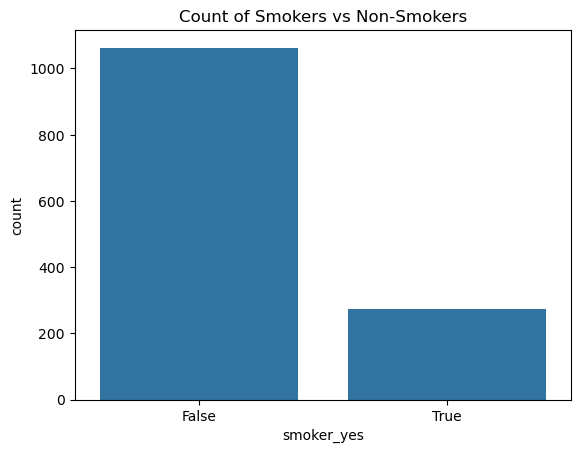

In [16]:
sns.countplot(x="smoker_yes", data=df)
plt.title("Count of Smokers vs Non-Smokers")

Text(0.5, 1.0, 'Age vs Charges')

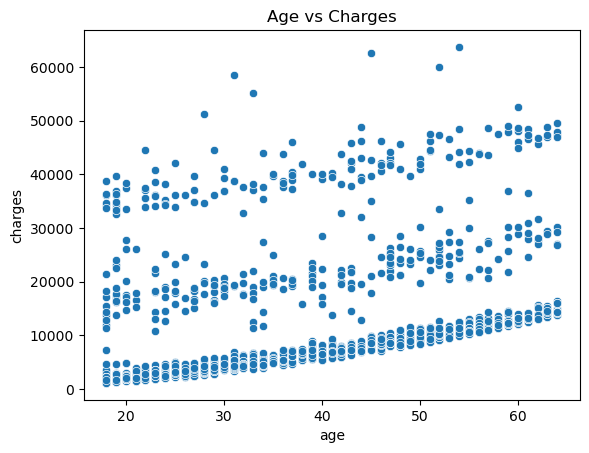

In [17]:
sns.scatterplot(x="age", y="charges", data=df)
plt.title("Age vs Charges")

Text(0.5, 1.0, 'Charges by Smoking Status')

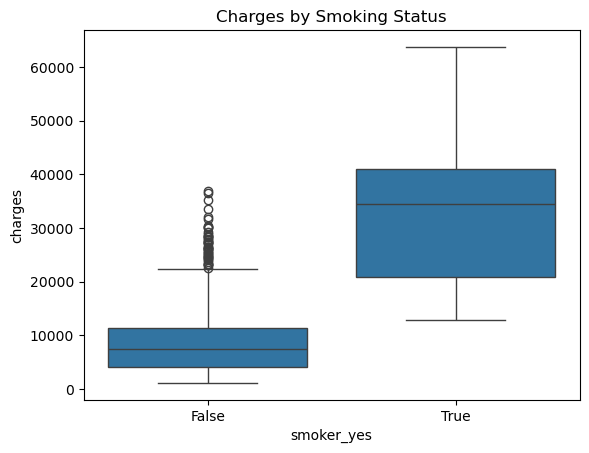

In [18]:
sns.boxplot(x="smoker_yes", y="charges", data=df)
plt.title("Charges by Smoking Status")

Text(0.5, 1.0, 'BMI vs Charges')

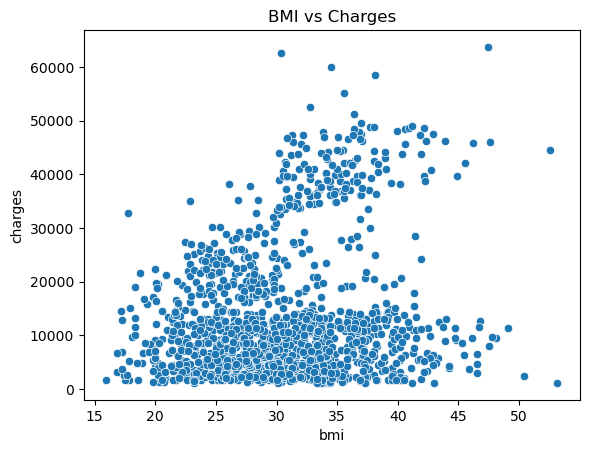

In [19]:
sns.scatterplot(x="bmi", y="charges", data=df)
plt.title("BMI vs Charges")

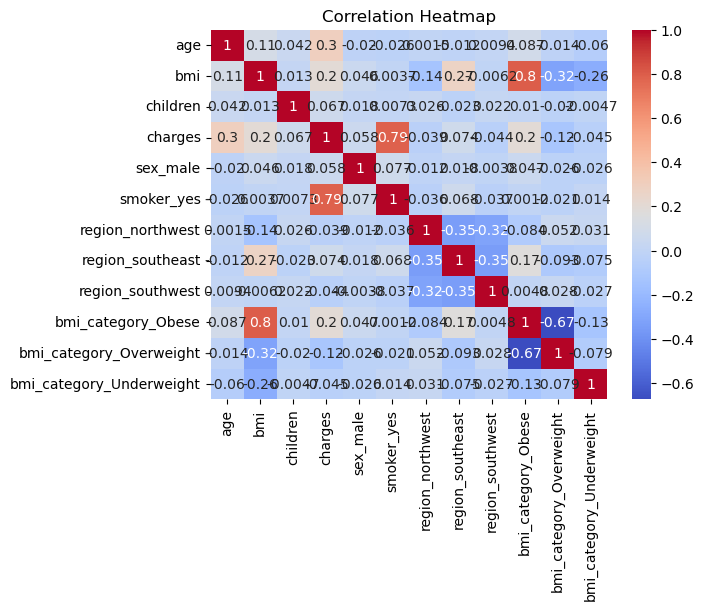

In [20]:
corr = df.corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [21]:
from sklearn.model_selection import train_test_split

X = df.drop("charges", axis=1)
y = df["charges"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [22]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [23]:
from sklearn.linear_model import Ridge

ridge = Ridge()
ridge.fit(X_train, y_train)

Ridge()

In [24]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)

DecisionTreeRegressor()

In [25]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

RandomForestRegressor()

In [26]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [27]:
from xgboost import XGBRegressor

xgb = XGBRegressor()
xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [29]:
pred = rf.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print(mae, rmse, r2)

2678.231782565672 4691.749588458149 0.8802079576765758


In [30]:
pip install mlflow

Note: you may need to restart the kernel to use updated packages.


In [31]:
import mlflow

with mlflow.start_run():

    rf = RandomForestRegressor()
    rf.fit(X_train, y_train)

    pred = rf.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    mlflow.log_metric("MAE", mae)
    mlflow.log_metric("RMSE", rmse)
    mlflow.log_metric("R2", r2)

    mlflow.sklearn.log_model(rf, "random_forest_model")

2026/03/24 08:52:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/24 08:52:24 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


In [33]:
import joblib

joblib.dump(rf, "insurance_model.pkl")
joblib.dump(X.columns, "columns.pkl")

['columns.pkl']

In [34]:
rf.fit(X_train, y_train)

# ADD BELOW THIS 👇
joblib.dump(rf, "insurance_model.pkl")
joblib.dump(X.columns, "columns.pkl")

['columns.pkl']